## Predicción de los Arrestos en los crímenes de Chigado
Este es el Notebook de Preprocesamiento


Listo al 18/01/25 2:31am

Dataset: Chicago_crimes_2021_2017

## Análisis de Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

%matplotlib inline

### Exporacion y Analisis de Datos para la Clasificación

Distribucion de delitos comentido basados en distritos

In [ ]:
crimes_procesado = pd.read_csv("crimenes_estratificado.csv")

**Mapa de calor de Crímenes por Distrito**

In [ ]:
crimes_procesado['Date'] = pd.to_datetime(crimes_procesado['Date'], errors='coerce')
crimes_procesado['Updated On'] = pd.to_datetime(crimes_procesado['Updated On'], errors='coerce')

missing_values = crimes_procesado.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
crimes_procesado['Hour'] = crimes_procesado['Date'].dt.hour
crimes_procesado['Month'] = crimes_procesado['Date'].dt.month

Dado que nuestra variable objetivo [Arrest] no tiene correlación fuerte con ninguna variable, se seleccionan las variables más representativas en el contexto del problema a tratar

In [ ]:
crimes_procesado.head()

,Unnamed: 0.1,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,...,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Dates,Time,Hour,Month
0,0,6214469,9421,28741,1970-01-01 00:00:00.000026657,2402,119,6,224,17,...,1157529.0,1895041.0,2016,1970-01-01 00:00:00.000000706,41.867752,-87.697156,1290,1512,0,1
1,1,2884818,19335,9469,1970-01-01 00:00:00.000008898,10782,12,25,35,91,...,1164172.0,1860620.0,2013,1970-01-01 00:00:00.000000184,41.773159,-87.673739,1290,1386,0,1
2,2,6165164,8514,27831,1970-01-01 00:00:00.000025841,436,257,22,133,61,...,1177641.0,1826048.0,2016,1970-01-01 00:00:00.000000599,41.677995,-87.625407,1290,1503,0,1
3,3,2572387,13117,3276,1970-01-01 00:00:00.000003101,9634,38,2,88,82,...,1172592.0,1867560.0,2012,1970-01-01 00:00:00.000000184,41.792022,-87.642669,1290,1420,0,1
4,4,3077565,23220,13371,1970-01-01 00:00:00.000012550,543,126,7,225,82,...,1175901.0,1901839.0,2014,1970-01-01 00:00:00.000000184,41.886013,-87.629505,1290,1408,0,1


In [ ]:
# Seleccion de características y Variable Objetivo
features = ['Primary Type','Beat', 'District', 'Ward','Community Area','Year', 'Hour', 'Month','Latitude','Longitude']
X = crimes_procesado[features]
y = crimes_procesado['Arrest']

<ipython-input-8-bacb8a6e3828>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


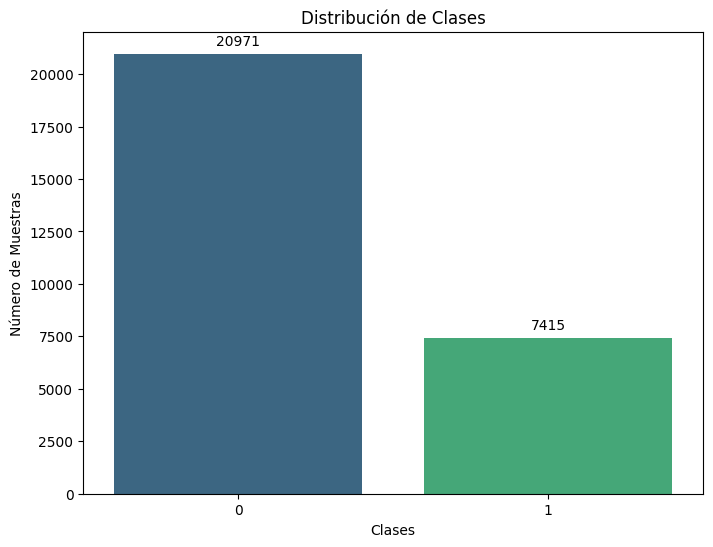

In [ ]:
# Función para graficar la distribución de las clases
def plot_class_distribution(y):
    class_counts = pd.Series(y).value_counts()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title("Distribución de Clases")
    plt.xlabel("Clases")
    plt.ylabel("Número de Muestras")
    for i, count in enumerate(class_counts.values):
        plt.text(i, count + 0.02 * max(class_counts.values), str(count), ha='center')
    plt.show()

# Graficar distribución de clases en el conjunto de datos original
plot_class_distribution(y)

**Tranformacion con PCA**

In [ ]:
pca = PCA()
X_PCA = pca.fit_transform(X)

print(f"Original crimes_procesado shape: {X.shape}")
print(f"PCA crimes_procesado shape: {X_PCA.shape}")

Original crimes_procesado shape: (28386, 10)
PCA crimes_procesado shape: (28386, 10)


In [ ]:
#Varianza explicada
cumulative_variance = pca.explained_variance_ratio_.cumsum()
print("Varianza acumulada:", cumulative_variance)


Varianza acumulada: [0.93048043 0.96642186 0.98763448 0.99971176 0.99992817 0.99999926
 0.99999984 1.         1.         1.        ]


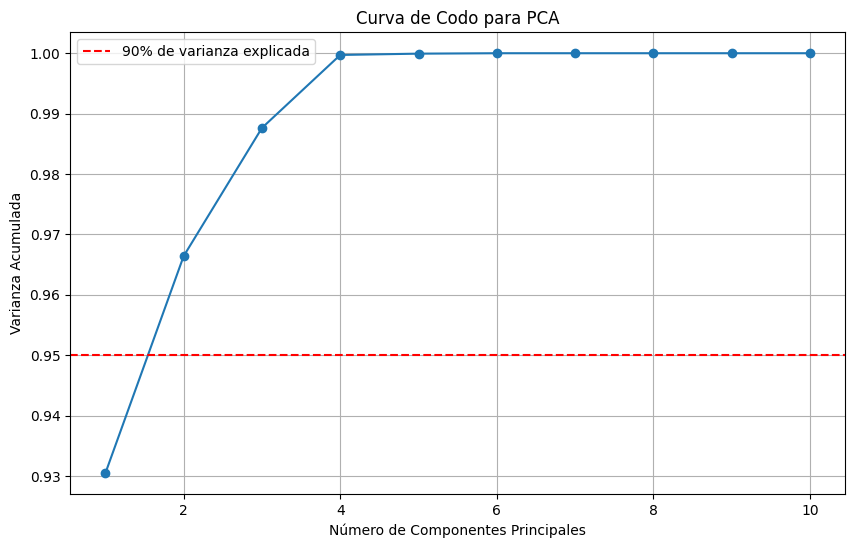

In [ ]:
# Graficar la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='90% de varianza explicada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.title('Curva de Codo para PCA')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Elegir el número de componentes principales que cubren al menos el 90% de la varianza
n_components = len(cumulative_variance[cumulative_variance <= 0.95]) + 1

# Aplicar PCA con el número óptimo de componentes
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)


**Submuestreo**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_test, y_train, y_test

(array([[ 92.34546211, -16.85692261],
        [ 13.83064528,  -7.38687238],
        [-33.70195927,  39.33840389],
        ...,
        [ 84.75798572,  -6.73474654],
        [ 95.16150266,  18.41098186],
        [-28.00663686,  10.77885165]]),
 array([[  68.44626796,  -15.25243022],
        [ -79.33263858,   -7.95856763],
        [-122.61065183,    1.53783955],
        ...,
        [-114.59168989,    1.90894113],
        [-103.97378072,    5.73652243],
        [  45.69772622,  -27.12936896]]),
 27831    1
 25206    1
 3574     0
 5684     0
 22035    1
         ..
 14880    0
 25310    1
 24336    1
 14977    0
 23923    1
 Name: Arrest, Length: 19870, dtype: int64,
 19216    0
 26655    1
 4017     0
 9927     0
 105      0
         ..
 20559    0
 12444    0
 24708    1
 24621    1
 21468    1
 Name: Arrest, Length: 8516, dtype: int64)

In [ ]:
X_train.shape

(19870, 2)

In [ ]:
y_train.shape

(19870,)

In [ ]:
X_test.shape

(8516, 2)

In [ ]:
y_test.shape

(8516,)

### Clasificacion

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, recall_score, roc_curve, auc, precision_recall_curve, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, precision_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


#### Random Forest

In [ ]:
#Creación del modelo.
modelRF = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, class_weight='balanced')
modelRF.fit(X_train, y_train)
y_predRF = modelRF.predict(X_test)

#Evaluar Modelo
accuracy = accuracy_score(y_test, y_predRF)
balanced_accuracy = balanced_accuracy_score(y_test, y_predRF)
recall = recall_score(y_test, y_predRF)
f1 = f1_score(y_test, y_predRF)
precision = precision_score(y_test, y_predRF)


#Métricas de medida
print(f"Accuracy: {accuracy}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1 Score: {f1}")

print(classification_report(y_test, y_predRF))

Accuracy: 0.7733677782996712
Balanced Accuracy: 0.694248998480083
Recall: 0.5285393258426966
Precision: 0.5717063684978123
F1 Score: 0.5492760392340028
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      6291
           1       0.57      0.53      0.55      2225

    accuracy                           0.77      8516
   macro avg       0.70      0.69      0.70      8516
weighted avg       0.77      0.77      0.77      8516



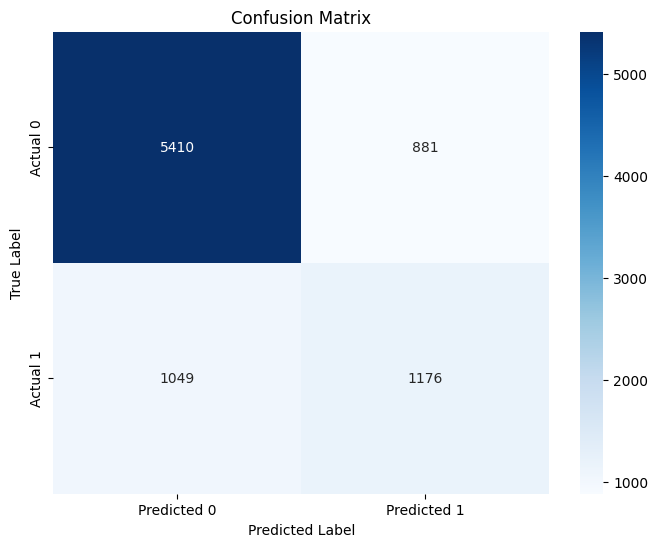

In [ ]:
conf_matrix = confusion_matrix(y_test, y_predRF)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### Gradient Boosting

In [ ]:
# Crear Modelo
modelGB = GradientBoostingClassifier(max_depth=5, min_samples_leaf=2, n_estimators=200, random_state=42)
modelGB.fit(X_train, y_train)

#Predicción
y_predGB = modelGB.predict(X_test)

#Calcular métricas
accuracy = accuracy_score(y_test, y_predGB)
balanced_accuracy = balanced_accuracy_score(y_test, y_predGB)
recall = recall_score(y_test, y_predGB)
precision = precision_score(y_test, y_predGB)
f1 = f1_score(y_test, y_predGB)

print(f"Accuracy: {accuracy}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1 Score: {f1}")

print(classification_report(y_test, y_predGB))

Accuracy: 0.7828792860497886
Balanced Accuracy: 0.5956778990496501
Recall: 0.20359550561797754
Precision: 0.8547169811320755
F1 Score: 0.32885662431941926
              precision    recall  f1-score   support

           0       0.78      0.99      0.87      6291
           1       0.85      0.20      0.33      2225

    accuracy                           0.78      8516
   macro avg       0.82      0.60      0.60      8516
weighted avg       0.80      0.78      0.73      8516



              precision    recall  f1-score   support

           0       0.78      0.99      0.87      6291
           1       0.85      0.20      0.33      2225

    accuracy                           0.78      8516
   macro avg       0.82      0.60      0.60      8516
weighted avg       0.80      0.78      0.73      8516



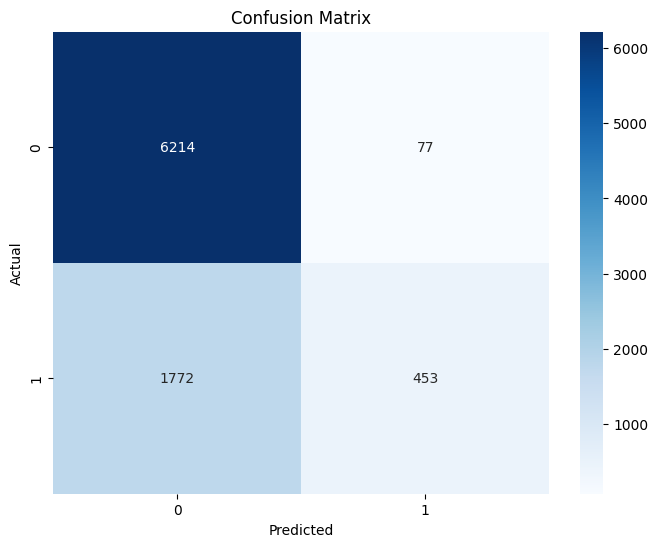

In [ ]:
print(classification_report(y_test, y_predGB))
#Confusion Matrix
cm = confusion_matrix(y_test, y_predGB)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Decision Tree

In [ ]:
#Tuneo de Hyperparamtros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_classifier = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_dt_model= grid_search.best_estimator_

print(f"Best Parameters: {best_dt_model}")

Best Parameters: DecisionTreeClassifier(criterion='entropy', random_state=42)


              precision    recall  f1-score   support

           0       0.84      0.86      0.85      6291
           1       0.57      0.54      0.56      2225

    accuracy                           0.77      8516
   macro avg       0.71      0.70      0.70      8516
weighted avg       0.77      0.77      0.77      8516



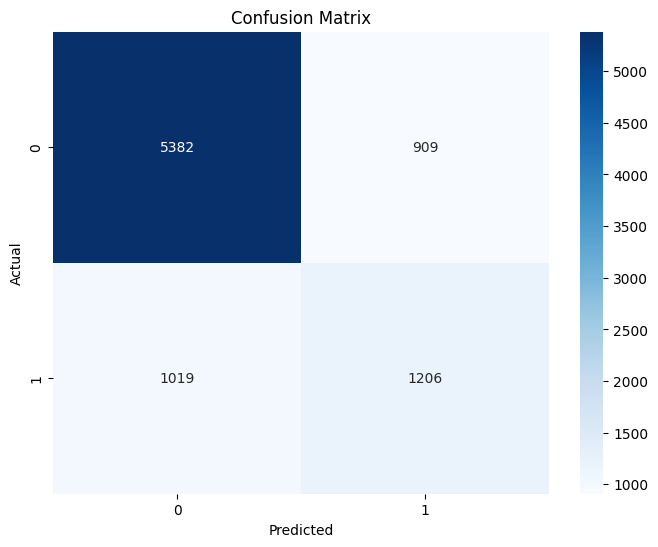

In [ ]:
#Predicción
y_predDT = best_dt_model.predict(X_test)

# Evaluación
print(classification_report(y_test, y_predDT))

# Confusion Matrix
cm = confusion_matrix(y_test, y_predDT)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_predDT)
balanced_accuracy = balanced_accuracy_score(y_test, y_predDT)
recall = recall_score(y_test, y_predDT)
precision = precision_score(y_test, y_predDT)
f1 = f1_score(y_test, y_predDT)

print(f"Accuracy: {accuracy}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1 Score: {f1}")

Accuracy: 0.773602630342884
Balanced Accuracy: 0.6987651701467585
Recall: 0.5420224719101123
Precision: 0.5702127659574469
F1 Score: 0.5557603686635945


#### Logistic Regression

In [ ]:
# Creacion y Evaluacion de Modelo
logisticR = LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000,penalty='l1',solver='saga')
logisticR.fit(X_train,y_train)
y_predLR = logisticR.predict(X_test)

# Metricas
accuracy = accuracy_score(y_test, y_predLR)
balanced_accuracy = balanced_accuracy_score(y_test, y_predLR)
recall = recall_score(y_test, y_predLR)
f1 = f1_score(y_test, y_predLR)

print(f"Accuracy: {accuracy}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 0.5294739314232034
Balanced Accuracy: 0.5066596296832107
Recall: 0.458876404494382
F1 Score: 0.33757645891882954


              precision    recall  f1-score   support

           0       0.74      0.55      0.64      6291
           1       0.27      0.46      0.34      2225

    accuracy                           0.53      8516
   macro avg       0.51      0.51      0.49      8516
weighted avg       0.62      0.53      0.56      8516



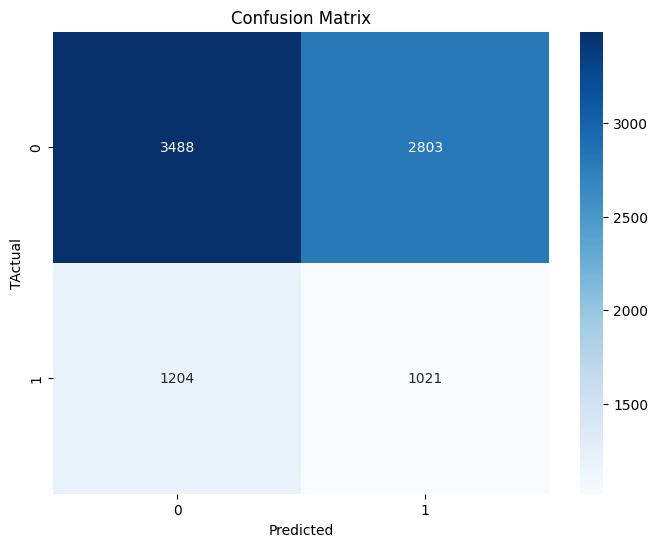

In [ ]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_predLR)

print(classification_report(y_test, y_predLR))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("TActual")
plt.show()

#### SVM

In [ ]:
print(classification_report(y_test, y_predSVM))
# Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Matriz de confusión')
plt.show()

NameError: name 'y_predSVM' is not defined

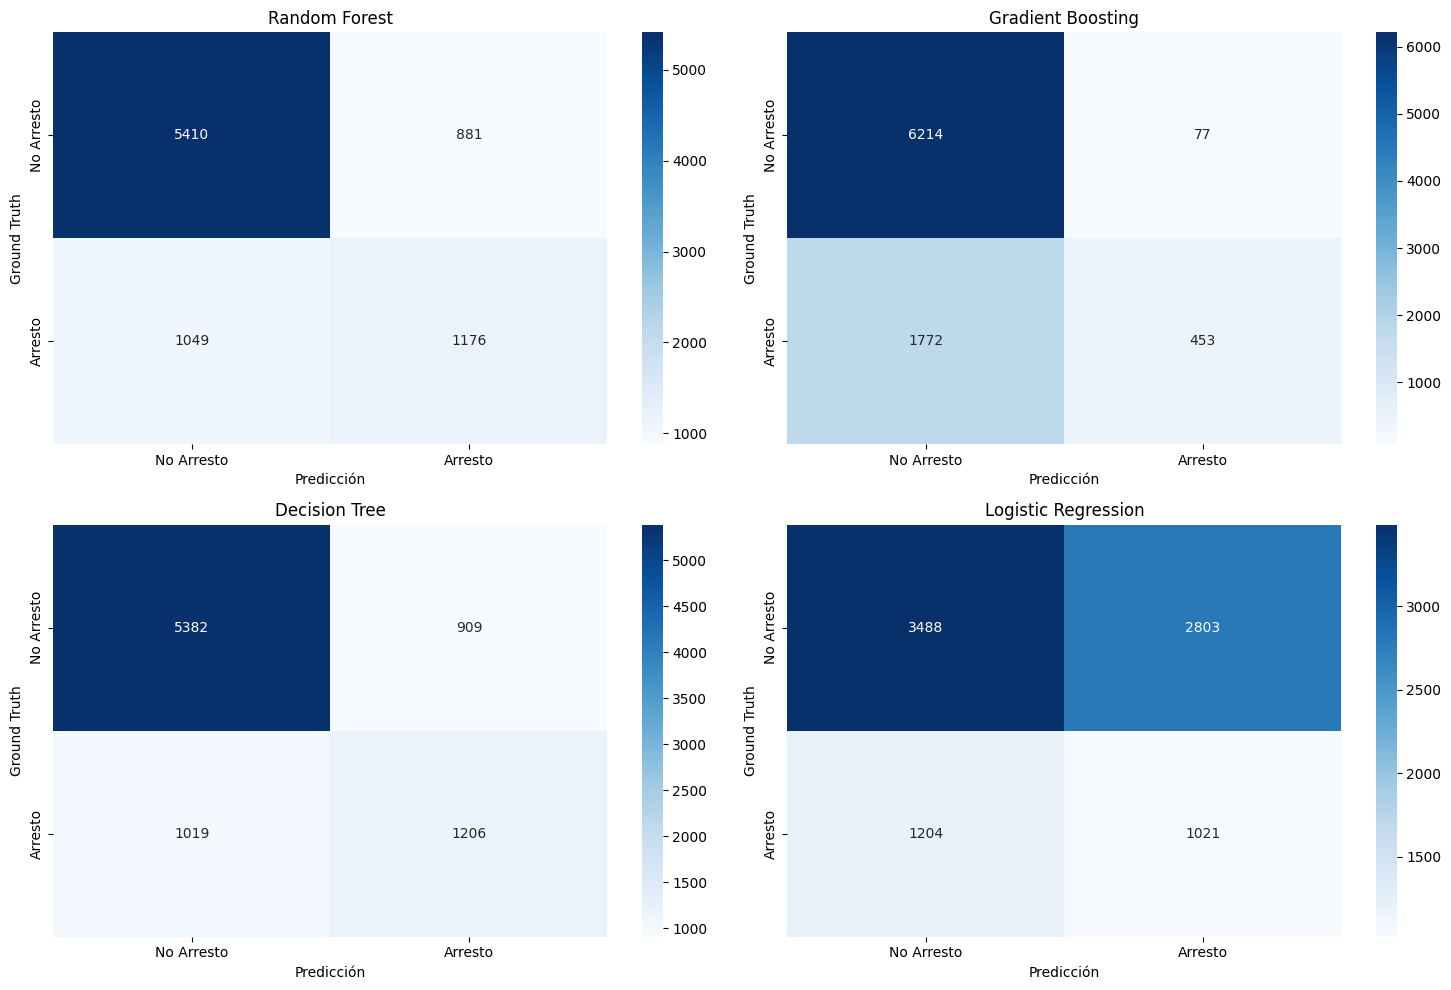

In [ ]:
def plot_confusion_matrices(models, X_test, y_test):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()  # Flatten the axes array

    model_names = ['Random Forest', 'Gradient Boosting', 'Decision Tree','Logistic Regression']
    model_predictions = [y_predRF, y_predGB, y_predDT, y_predLR]


    for i, (name, y_pred) in enumerate(zip(model_names, model_predictions)):
        conf_matrix = confusion_matrix(y_test, y_pred)
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['No Arresto', 'Arresto'],
                    yticklabels=['No Arresto', 'Arresto'], ax=axes[i])
        axes[i].set_title(f"{name}")
        axes[i].set_xlabel("Predicción")
        axes[i].set_ylabel("Ground Truth")

    # Hide any unused subplots if less than 6 models are provided
    for j in range(len(model_names), len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_confusion_matrices([modelRF, modelGB, best_dt_model, logisticR], X_test, y_test)